####  EXPLORATORY DATA ANALYSIS 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/Crop_recommendation.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [4]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [5]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [7]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [8]:
df.shape

(2200, 8)

In [9]:
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [10]:
df['label'].unique()

<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

Handling missing data + outliers

In [11]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [12]:
(df == 0).sum()

N              27
P               0
K               0
temperature     0
humidity        0
ph              0
rainfall        0
label           0
dtype: int64

In [13]:
df[df['N'] == 0]['label'].value_counts()

label
lentil         4
orange         4
coconut        4
pomegranate    3
mango          3
apple          3
kidneybeans    2
pigeonpeas     1
mothbeans      1
mungbean       1
grapes         1
Name: count, dtype: int64

In [14]:
df = df[df['N']!=0]

In [15]:
print(2200 - len(df))

27


In [16]:
(df == 0).sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [17]:
Q1 = df['N'].quantile(0.25)

In [18]:
Q3 = df['N'].quantile(0.75)

In [19]:
IQR = Q3-Q1

In [20]:
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [21]:
df_clean = df[(df['N'] >= lower) & (df['N'] <= upper)]

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

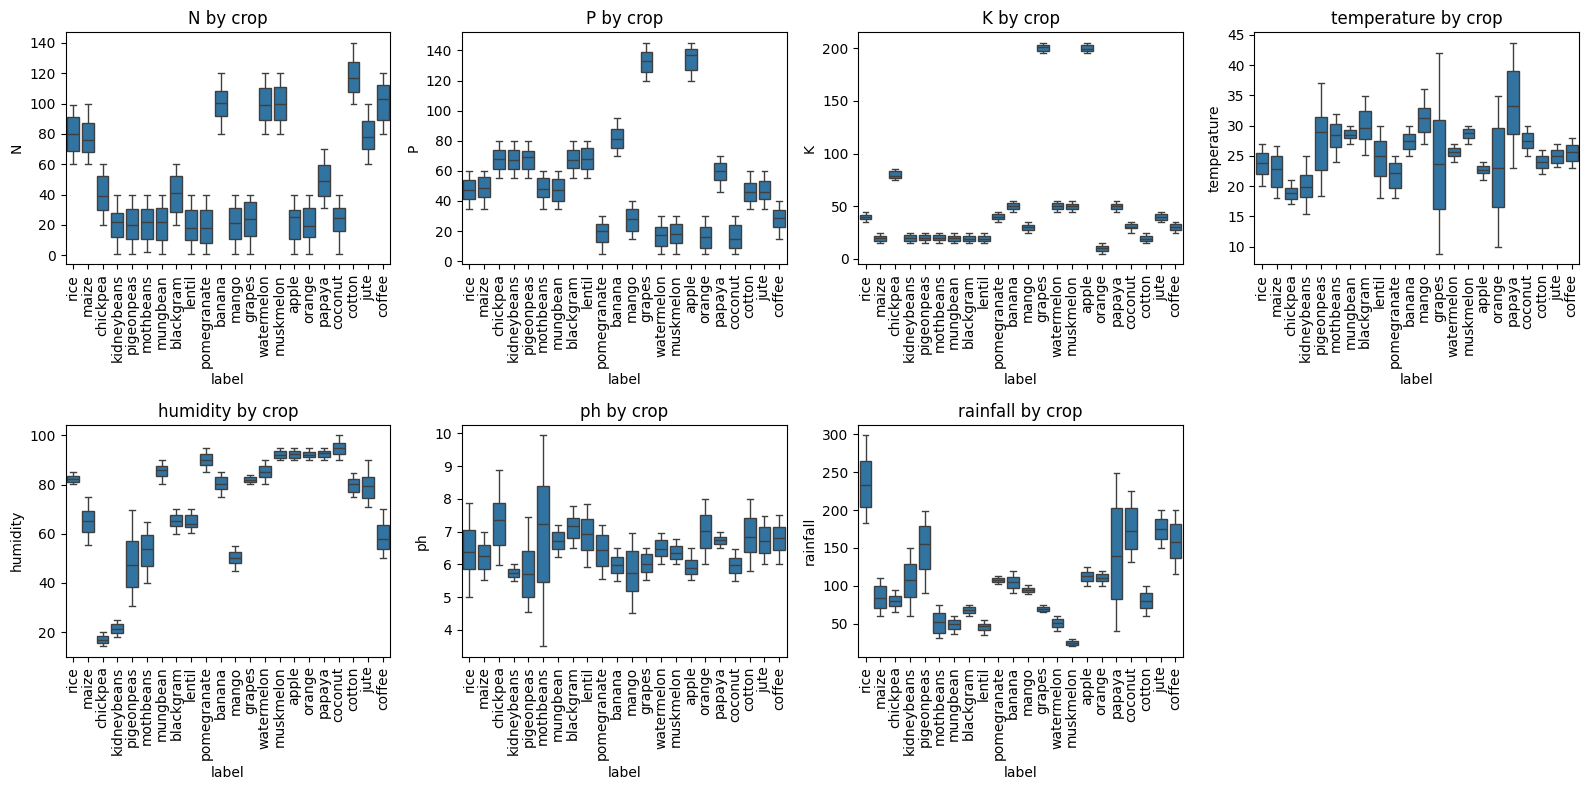

In [23]:
features = ['N','P','K','temperature','humidity','ph','rainfall']

fig, axes = plt.subplots(2,4, figsize=(16,8))
axes = axes.flatten()

for i,cols in enumerate(features):
    sns.boxplot(data = df, x='label', y=cols, ax=axes[i])
    axes[i].set_title(f'{cols} by crop')
    axes[i].tick_params(axis='x',rotation=90)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/boxplots.png', dpi=150)
plt.show()

Feature engineering - label encoding, scaling, test_train_split

In [24]:
from sklearn.preprocessing import LabelEncoder

In [25]:
LE = LabelEncoder()
df['crop_encoded'] = LE.fit_transform(df['label'])

In [26]:
mapping = dict(zip(LE.classes_, LE.transform(LE.classes_)))
print(mapping)

{'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


In [27]:
import joblib

joblib.dump(LE, '../models/label_encoder.pkl')
print("saved label encoder")

saved label encoder


must save LE with joblib.dump because when your fastapi endpoint predicts 2, it needs the encoder to turn that back into 'blackgram'. if you dont save it, you will have to retrain just to decode outputs.

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
feature_cols =  ['N','P','K','temperature','humidity','ph','rainfall']

X= df[feature_cols].values
y = df['crop_encoded'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size: {X_train_raw.shape}')
print(f"test_size: {X_test_raw.shape}")


Train size: (1738, 7)
test_size: (435, 7)


In [30]:
#verify stratification
import numpy as np
unique, train_counts = np.unique(y_train, return_counts=True)
_, test_counts= np.unique(y_test, return_counts=True)
for i, crop in enumerate(LE.classes_):
    print(f"{crop:15s} train:{train_counts[i]:4d} test: {test_counts[i]:3d}")

apple           train:  78 test:  19
banana          train:  80 test:  20
blackgram       train:  80 test:  20
chickpea        train:  80 test:  20
coconut         train:  77 test:  19
coffee          train:  80 test:  20
cotton          train:  80 test:  20
grapes          train:  79 test:  20
jute            train:  80 test:  20
kidneybeans     train:  78 test:  20
lentil          train:  77 test:  19
maize           train:  80 test:  20
mango           train:  78 test:  19
mothbeans       train:  79 test:  20
mungbean        train:  79 test:  20
muskmelon       train:  80 test:  20
orange          train:  77 test:  19
papaya          train:  80 test:  20
pigeonpeas      train:  79 test:  20
pomegranate     train:  77 test:  20
rice            train:  80 test:  20
watermelon      train:  80 test:  20


In [31]:
from sklearn.preprocessing import StandardScaler


In [32]:

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc = scaler.transform(X_test_raw)

print("means:", X_train_sc.mean(axis=0).round(3))

print("stds:", X_train_sc.std(axis=0).round(3) )

joblib.dump(scaler, '../models/scaler.pkl')
print("saved scaler")

means: [-0.  0. -0. -0. -0. -0.  0.]
stds: [1. 1. 1. 1. 1. 1. 1.]
saved scaler


Visualisations

In [33]:
import seaborn as sns

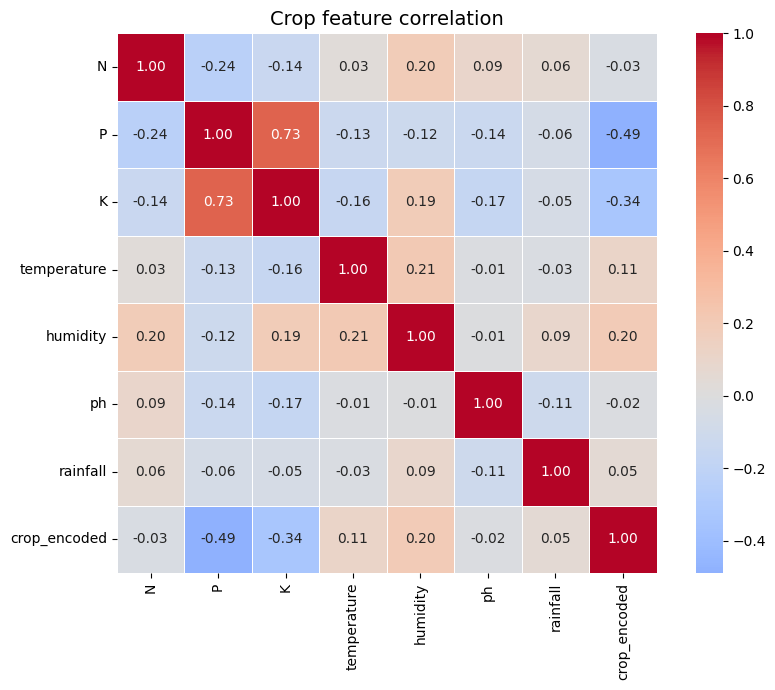

In [34]:
plt.figure(figsize=(9,7))
numeric_df = df.drop(columns=['label'])
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt ='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Crop feature correlation', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/heatmap.png',dpi=150)
plt.show()

Histogram for feature distribution per crop

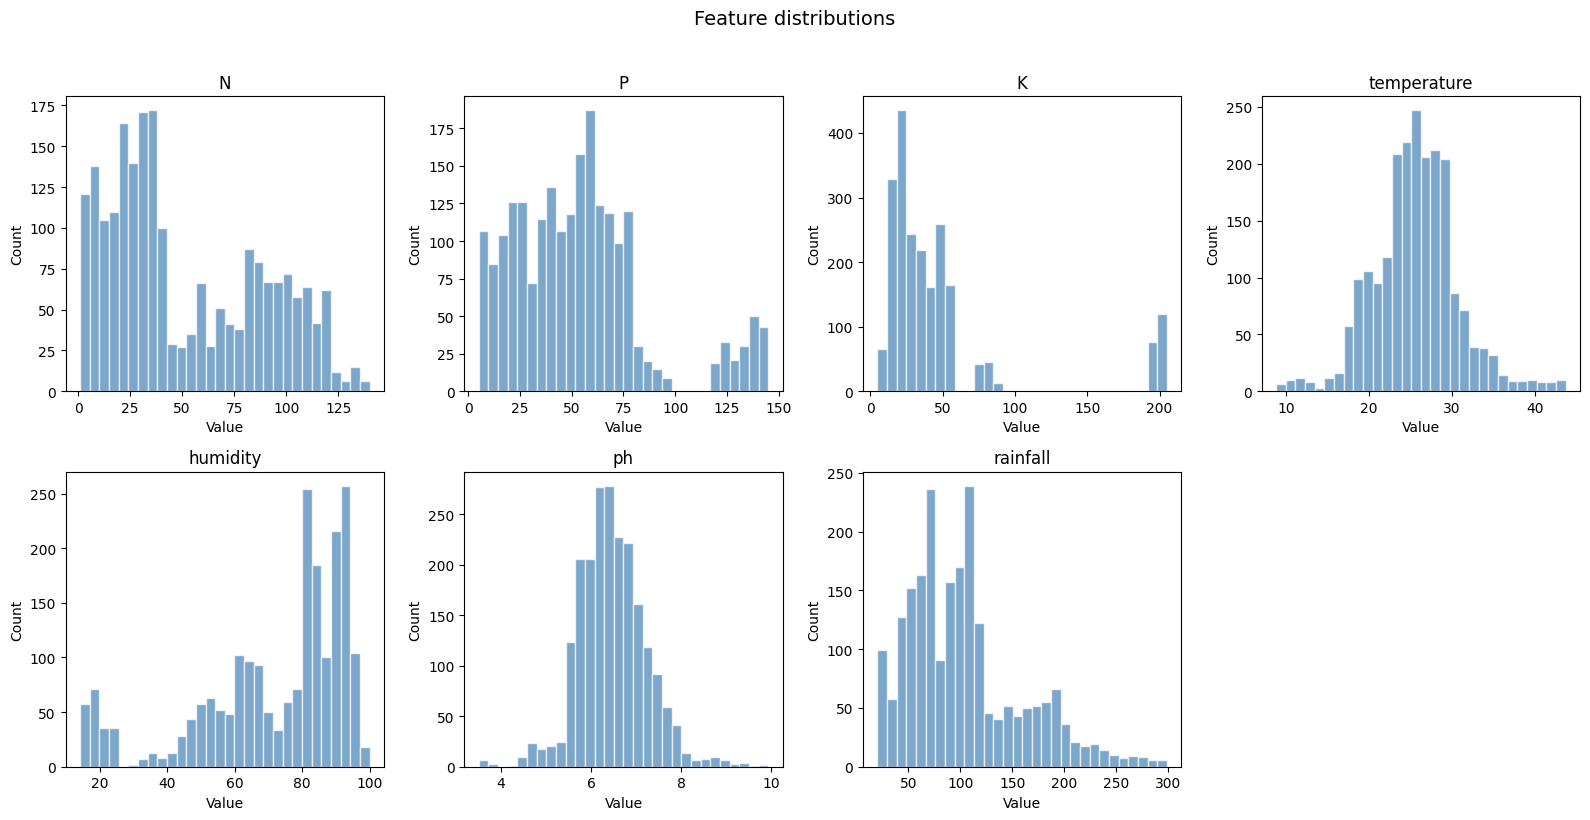

In [35]:
features = ['N','P','K','temperature','humidity','ph','rainfall']

fig, axes = plt.subplots(2,4, figsize=(16,8))
axes = axes.flatten()

for i,features in enumerate(features):
    axes[i].hist(df[features],bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].set_title(features,fontsize =12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Feature distributions', fontsize =14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/distributions.png', dpi=150)
plt.show()

Boxplot- feature per crop
(picking top 6 crops so its readable)

C:\Users\vivaa\AppData\Local\Temp\ipykernel_15376\751317351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x ='label', y='N', palette='Set2')


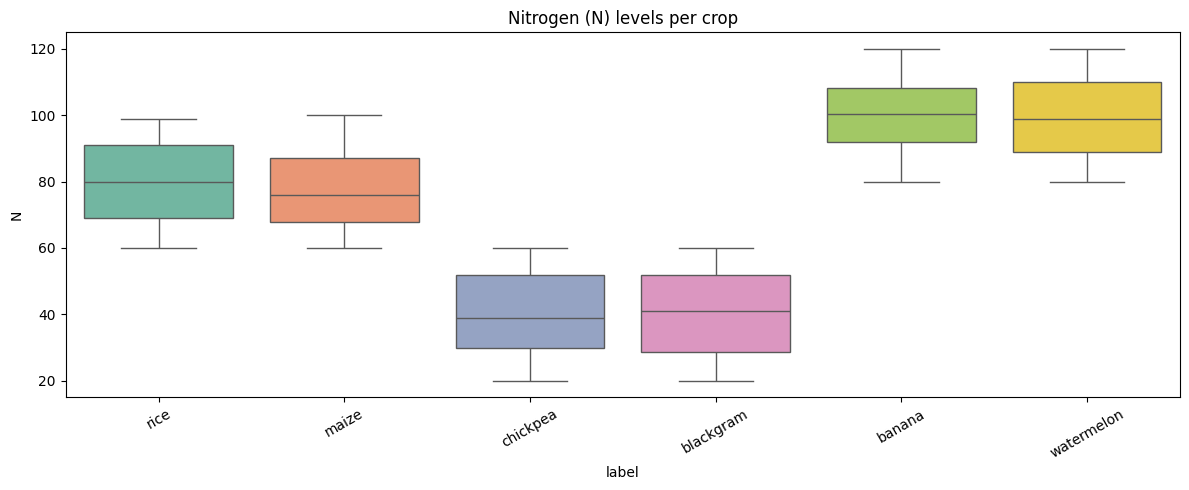

In [36]:
top_crops=df['label'].value_counts().head(6).index
df_top= df[df['label'].isin(top_crops)]

plt.figure(figsize=(12,5))
sns.boxplot(data=df_top, x ='label', y='N', palette='Set2')
plt.title('Nitrogen (N) levels per crop')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/boxplot_N.png', dpi = 120)
plt.show()

Pairplot of key features

In [37]:
# df_sample = df.sample(200, random_state=42)
# sns.pairplot(df_sample[['N','K','ph','rainfall','label']],
#             hue='label', plot_kws={'aplha': 0.5}, diag_kind='kde')
# plt.suptitle('Pairplot of key features', y= 1.02)
# plt.savefig('pairplot.png',dpi =120)
# plt.show()

Baseline models

In [38]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200, C=2.0)
lr.fit(X_train_sc,y_train)
print("LR Train accuracy:", round(lr.score(X_train_sc,y_train)*100,2), "%")
print("LR Test accuracy:", round(lr.score(X_test_sc,y_test)*100,2), "%")


LR Train accuracy: 97.87 %
LR Test accuracy: 96.78 %


train accuracy: 99.37 %
test accuracy: 98.85 %


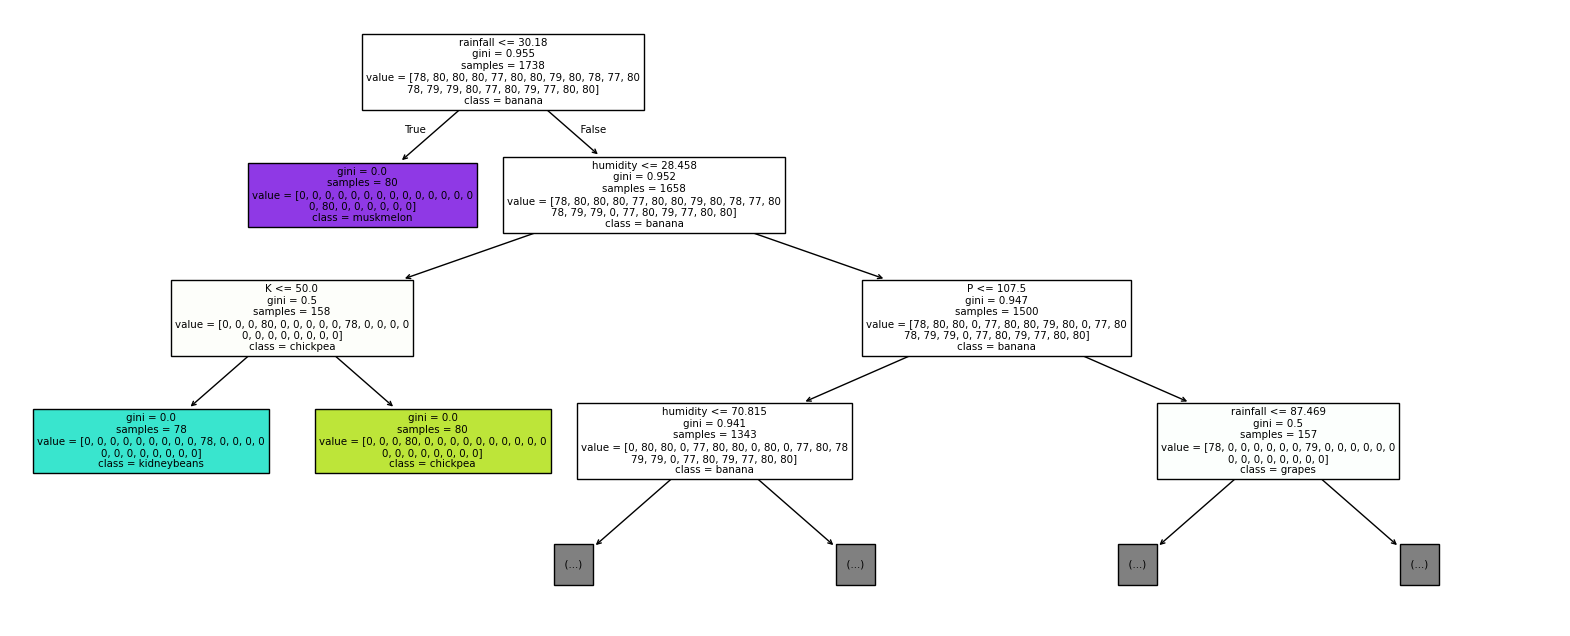

In [39]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=5,
    criterion='gini',
    random_state=42
)

dt.fit(X_train_raw,y_train)   #no scaling needed for trees

print("train accuracy:", round(dt.score(X_train_raw,y_train)*100,2), "%")
print("test accuracy:", round(dt.score(X_test_raw,y_test)*100,2), "%")

feature_list=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

from sklearn.tree import plot_tree
plt.figure(figsize=(20,8))
plot_tree(dt,max_depth=3,feature_names=feature_list,
        class_names=LE.classes_, filled=True)
plt.savefig("../outputs/decision_tree.png", dpi=100, bbox_inches='tight')
plt.show()


In [40]:
#dt won so saving it as baseline model
joblib.dump(dt,'../models/baseline_model.pkl')
print("saved : models/baseline_odel.pkl")

saved : models/baseline_odel.pkl


In [41]:
#quick sanity check- load and predict
loaded = joblib.load('../models/baseline_model.pkl')
sample = X_test_raw[:1]
print("Test prediction:", LE.inverse_transform(loaded.predict(sample)))

Test prediction: ['maize']


Evaluation metrics

In [42]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [43]:
# get predictions from both models
lr_pred= lr.predict(X_test_sc)
dt_pred= dt.predict(X_test_raw)

#Compare models
def evaluate_model(name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f"model: {name}")
    print(f"{'='*40}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=LE.classes_))

evaluate_model("LR", y_test,lr_pred)
evaluate_model("DT", y_test,dt_pred)




model: LR
Accuracy: 0.9678
Precision: 0.9694
Recall   : 0.9679
F1 Score : 0.9673

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        19
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.97        19
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.95      0.95        19
       maize       1.00      1.00      1.00        20
       mango       0.95      1.00      0.97        19
   mothbeans       0.94      0.75      0.83        20
    mungbean       0.95      1.00      0.98        20
   muskmelon       1.00      1.00      1.00        2

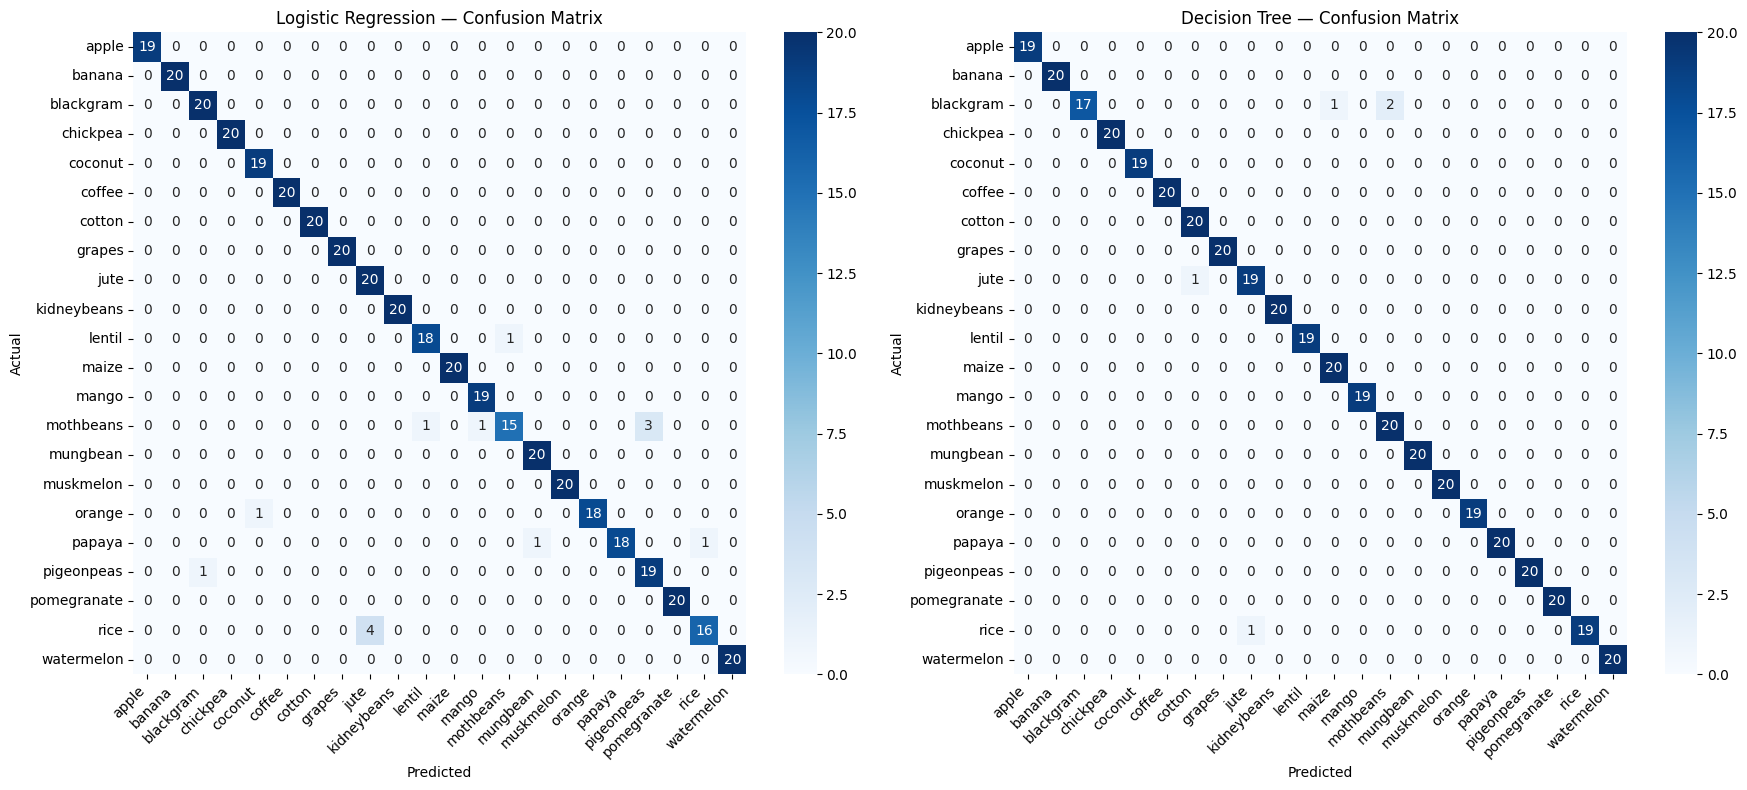

In [44]:
# confusion matrix heatmap
fig, axes= plt.subplots(1,2,figsize=(18,8))

for ax, preds, name in zip(axes, [lr_pred, dt_pred],
                            ["Logistic Regression", "Decision Tree"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LE.classes_,
                yticklabels=LE.classes_, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150)
plt.show()

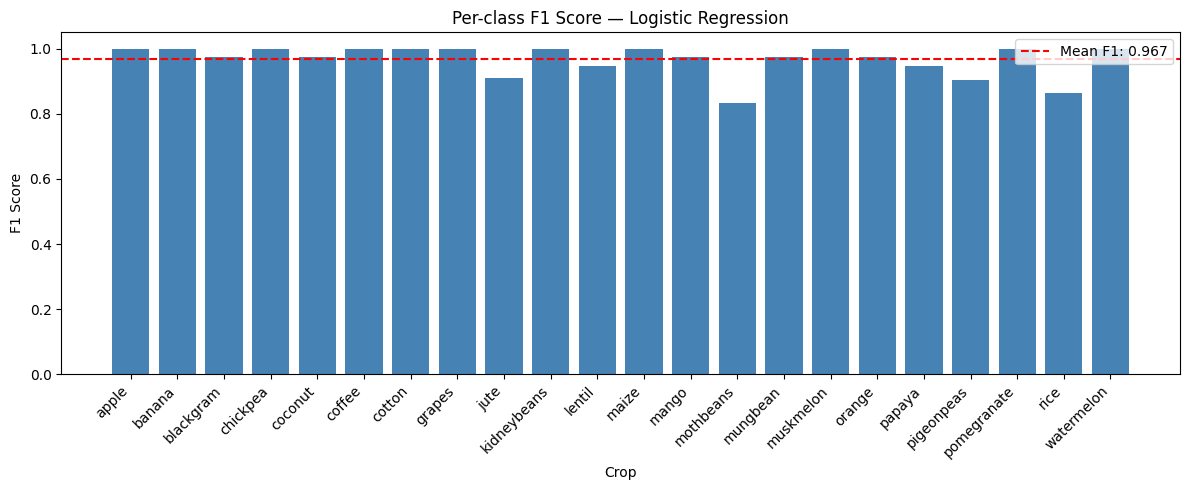

In [45]:
# per class F1 bar chart
f1_per_class = f1_score(y_test, lr_pred, average=None)
plt.figure(figsize=(12, 5))
bars = plt.bar(LE.classes_, f1_per_class, color='steelblue')
plt.axhline(y=f1_per_class.mean(), color='red',
            linestyle='--', label=f'Mean F1: {f1_per_class.mean():.3f}')
plt.xlabel('Crop')
plt.ylabel('F1 Score')
plt.title('Per-class F1 Score — Logistic Regression')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/per_class_f1.png', dpi=150)
plt.show()

In [46]:
#for quick load of models and return exact json , api will return
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    model  = joblib.load('../models/baseline_model.pkl')
    scaler = joblib.load('../models/scaler.pkl')
    le     = joblib.load('../models/label_encoder.pkl')

    X = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    pred = model.predict(X)   
    crop = le.inverse_transform(pred)[0]
    return {'crop': crop}

# Test it — rice conditions
rice_row = df[df['label'] == 'rice'].iloc[0]
print("Real rice values:", rice_row[feature_cols].values)
result = predict_crop(*rice_row[feature_cols].values)
print("Predicted:", result)


Real rice values: [np.int64(90) np.int64(42) np.int64(43) np.float64(20.87974371)
 np.float64(82.00274423) np.float64(6.502985292000001)
 np.float64(202.9355362)]
Predicted: {'crop': 'rice'}


#### ML Depth

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    max_depth=None,
    n_estimators=100,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1 #use all CPU cores
)

rf.fit(X_train_sc,y_train)

train_acc = rf.score(X_train_sc,y_train)*100
test_acc = rf.score(X_test_sc,y_test)*100

print(f"train accuracy:  {train_acc:.2f}")
print(f"test accuracy:  {test_acc:.2f}")
print(f"overfit gap: {(train_acc-test_acc):.2f}")

joblib.dump(rf, '../models/rf_model.pkl')

train accuracy:  100.00
test accuracy:  99.77
overfit gap: 0.23


['../models/rf_model.pkl']

cv mean: 0.9948 ± 0.0034


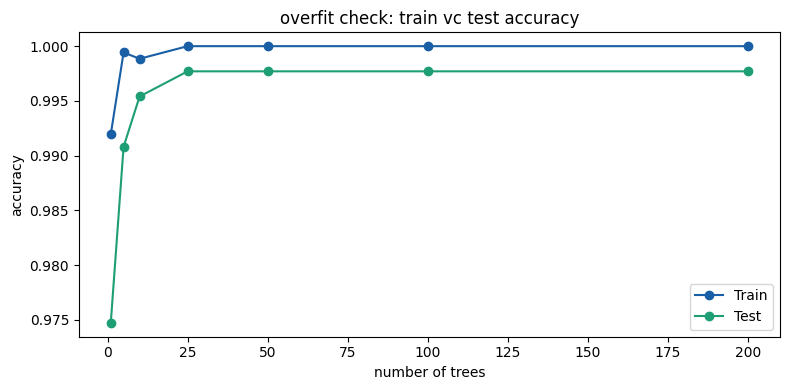

In [48]:
tree_counts = [1,5,10,25,50,100,200]
train_Scores, test_Scores= [],[]

for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train_sc,y_train)
    train_Scores.append(model.score(X_train_sc,y_train))
    test_Scores.append(model.score(X_test_sc,y_test))

plt.figure(figsize=(8,4))
plt.plot(tree_counts,train_Scores, 'o-', label='Train', color ='#185FA5')
plt.plot(tree_counts,test_Scores, 'o-', label='Test', color ='#1D9E75')
plt.xlabel("number of trees")
plt.ylabel("accuracy")
plt.title("overfit check: train vc test accuracy")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/overfit_curve.png',dpi = 150)

from sklearn.model_selection import cross_val_score
cv_Scores = cross_val_score(rf, X_train_sc, y_train, cv = 5)
print(f"cv mean: {cv_Scores.mean():.4f} ± {cv_Scores.std():.4f}")

|--- humidity <= -1.93
|   |--- K <= 0.04
|   |   |--- class: 9.0
|   |--- K >  0.04
|   |   |--- class: 3.0
|--- humidity >  -1.93
|   |--- P <= 1.64
|   |   |--- K <= -0.67
|   |   |   |--- class: 16.0
|   |   |--- K >  -0.67
|   |   |   |--- humidity <= 0.11
|   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- humidity >  0.11
|   |   |   |   |--- truncated branch of depth 11
|   |--- P >  1.64
|   |   |--- N <= -0.42
|   |   |   |--- humidity <= 0.69
|   |   |   |   |--- class: 7.0
|   |   |   |--- humidity >  0.69
|   |   |   |   |--- class: 0.0
|   |   |--- N >  -0.42
|   |   |   |--- temperature <= -0.27
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- temperature >  -0.27
|   |   |   |   |--- class: 7.0



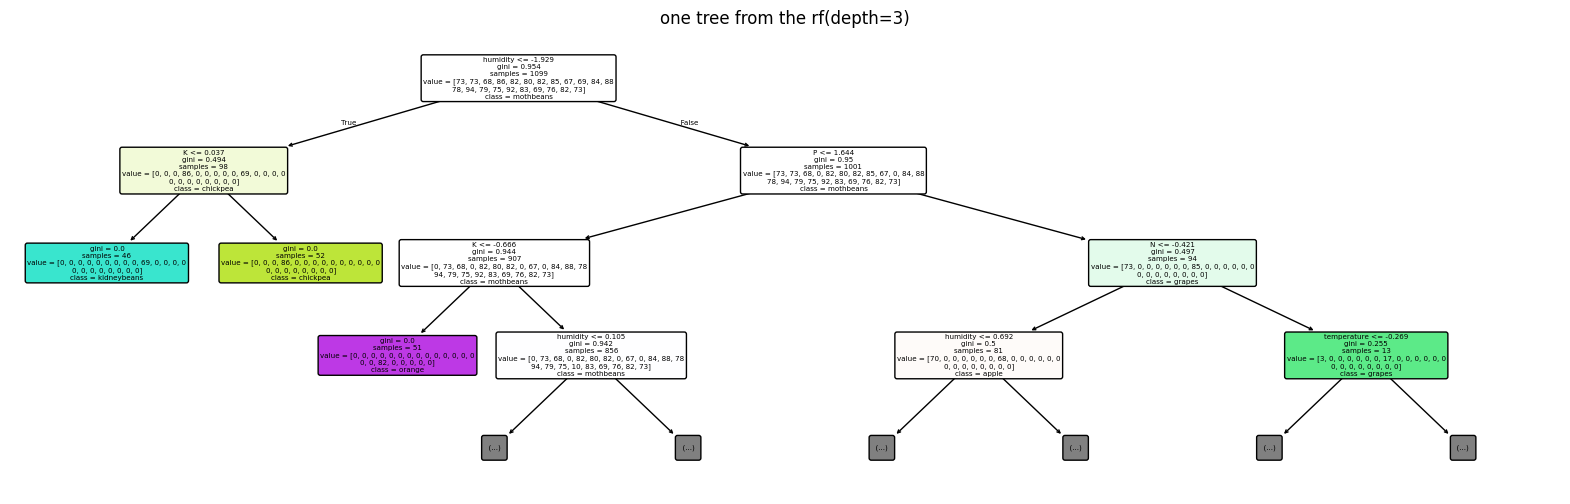

In [49]:
from sklearn.tree import export_text, plot_tree

feature_names= ['N','P','K','temperature','humidity','ph','rainfall' ]

single_tree = rf.estimators_[0]
print(export_text(single_tree,
                  feature_names=feature_names, max_depth=3))

fig,ax = plt.subplots(figsize =(20,6))
plot_tree(single_tree,feature_names=feature_names,
          class_names= LE.classes_,
          max_depth=3,
          filled=True,
          rounded=True,
          ax=ax)

plt.title("one tree from the rf(depth=3)")
plt.savefig("../outputs/one_tree.png", dpi=120, bbox_inches ='tight')

In [50]:
from xgboost import XGBClassifier

In [51]:
model = XGBClassifier()
print("ok")

ok


In [52]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0

)

xgb.fit(X_train_raw,y_train)

train_Acc = accuracy_score(y_train, xgb.predict(X_train_raw))
test_acc = accuracy_score(y_test, xgb.predict(X_test_raw))
print(f"train: {train_Acc:.4f} | test: {test_acc : .4f} | gap: { train_Acc-test_acc:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, xgb.predict(X_test_raw),
                            target_names=LE.classes_))


train: 1.0000 | test:  1.0000 | gap: 0.0000

 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        19
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        19
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      1.00      1.00        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        19
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange

Feature importance

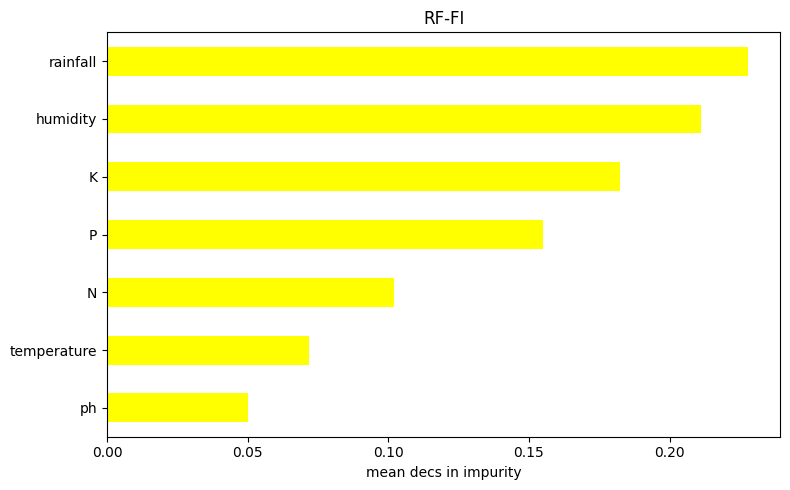

Top features:
rainfall       0.227878
humidity       0.211050
K              0.182359
P              0.154822
N              0.102117
temperature    0.071716
ph             0.050058
dtype: float64


In [53]:
# random forest importance 
importances = pd.Series(rf.feature_importances_, index= feature_names)
importances_sorted = importances.sort_values(ascending = True)

plt.figure(figsize=(8,5))
importances_sorted.plot(kind = 'barh', color = "yellow")
plt.title("RF-FI")
plt.xlabel('mean decs in impurity')
plt.tight_layout()
plt.savefig('../outputs/rf_imp.png', dpi =150)
plt.show()

print('Top features:')
print(importances.sort_values(ascending = False))

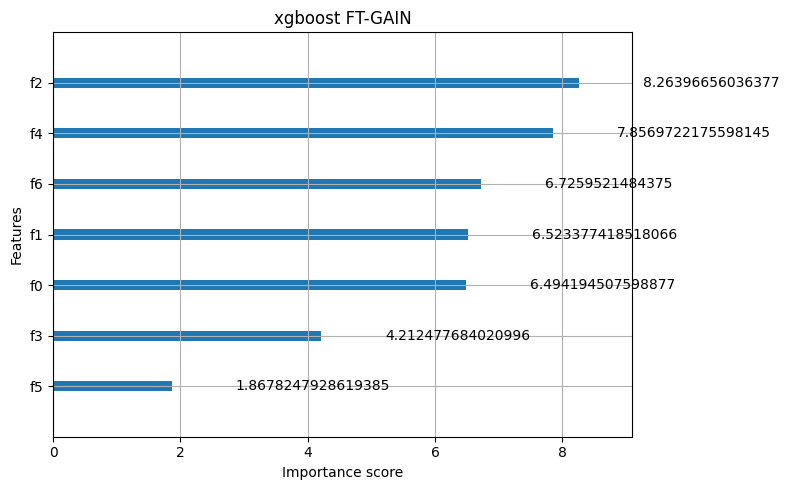

In [54]:
#  xgboost importance

from xgboost import plot_importance

fig,ax = plt.subplots(figsize =(8,5))
plot_importance(xgb, ax=ax,importance_type = 'gain',
                title='xgboost FT-GAIN')
plt.tight_layout()
plt.savefig('../outputs/xgb_imp.png',dpi=150)
plt.show()


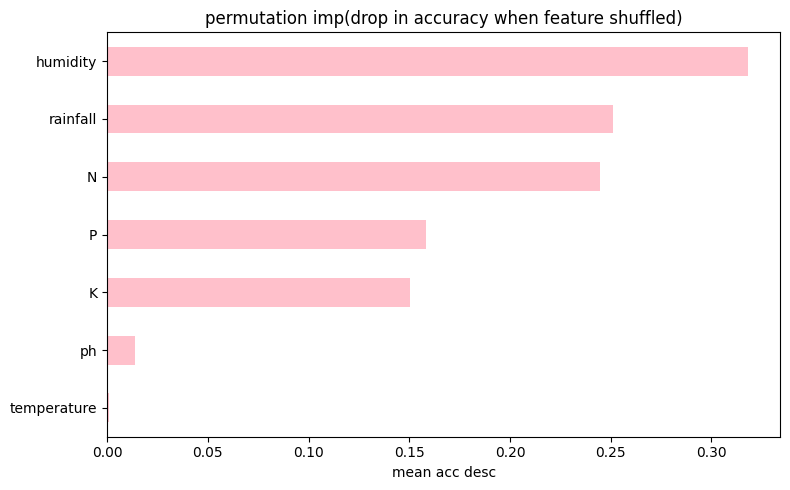

In [55]:
#  permutation importance (most reliable)
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X_test_sc, y_test,
    n_repeats= 10,  #shuffle each feature 10 times
    random_state= 42,
    n_jobs= 1
)

perm_imp = pd.Series(result.importances_mean,index= feature_names)
perm_imp_sorted = perm_imp.sort_values(ascending = True)

plt.figure(figsize=(8,5))
perm_imp_sorted.plot(kind='barh', color ='pink')
plt.title('permutation imp(drop in accuracy when feature shuffled)')
plt.xlabel('mean acc desc')
plt.tight_layout()
plt.savefig('../outputs/perm_imp.png', dpi =150)
plt.show()


In [56]:
#  drop weak features and retrain

threshold = 0.05 #drop features with imp below this

important_features = importances[importances> threshold].index.tolist()
print(f"keeping: {important_features}")
print(f"dropping : {[f for  f in feature_names if f not in important_features]}")

idx = [feature_names.index(f) for f  in important_features]
X_train_slim = X_train_sc[:,idx]
X_test_slim = X_test_sc[:,idx]

rf_slim = RandomForestClassifier(n_estimators=200, random_state=42)
rf_slim.fit(X_train_slim,y_train)

print(f"slim model acc: {rf_slim.score(X_test_slim, y_test):.4f}")


keeping: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
dropping : []
slim model acc: 0.9977


Hyperparameter tuning

In [57]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, n_jobs = -1))
])

param_grid = {
    'model__n_estimators': [100,200,300],
    'model__max_depth': [5,10,None],
    'model__min_samples_split': [2,5],
}
#  total combos = 3*3*2 = 18 combos * 5folds = 90 model fits

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5, # 5-fold corss validation
    scoring= 'accuracy',
    n_jobs=-1, #use all cpu cores in parallel
    verbose = 2, # print prgress as it runs
    return_train_score= True
)

grid_search.fit(X_train_sc,y_train)

print("best params:" , grid_search.best_params_)
print("best cv score:", round(grid_search.best_score_ * 100, 2), "%")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_sc)
print("\ntest set performance:")
print(classification_report(y_test, y_pred,target_names=LE.classes_))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
best params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
best cv score: 99.48 %

test set performance:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        19
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        19
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        19
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      1.00      

In [58]:
#diagnose if overfit
results = pd.DataFrame(grid_search.cv_results_)

#compare train score with validation score
results['overfit_gap'] = results['mean_train_score'] - results['mean_test_score']

top5 = results.sort_values('mean_test_score', ascending=False).head(5)
print(top5[['params', 'mean_train_score', 'mean_test_score', 'overfit_gap']])


                                               params  mean_train_score  \
10  {'model__max_depth': 10, 'model__min_samples_s...          0.997411   
11  {'model__max_depth': 10, 'model__min_samples_s...          0.997555   
7   {'model__max_depth': 10, 'model__min_samples_s...          0.997411   
12  {'model__max_depth': None, 'model__min_samples...          1.000000   
9   {'model__max_depth': 10, 'model__min_samples_s...          0.997699   

    mean_test_score  overfit_gap  
10         0.994826     0.002585  
11         0.994826     0.002729  
7          0.994824     0.002587  
12         0.994824     0.005176  
9          0.994251     0.003447  


In [59]:
joblib.dump(best_model, '../models/crop_best_model.pkl')

print("model saved! Best params:", grid_search.best_params_)


model saved! Best params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [60]:
#xgb pipeline

xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',XGBClassifier(random_state =42, eval_metric = 'mlogloss', verbosity=0))
])

xgb_grid={
    'model__n_estimators':[100,200],
    'model__learning_rate':[0.05,0.1,0.2],
    'model__max_depth':[4,6,8],
}

xgb_search = GridSearchCV(xgb_pipe,
                          xgb_grid , 
                          cv=5,
                          scoring='accuracy',
                          n_jobs=-1)
xgb_search.fit(X_train_sc,y_train)

print("XGBoost best params:", xgb_search.best_params_)
print("XGBoost best cv score:", round(xgb_search.best_score_ * 100,2),"%")

#compare both
print(f'\nRandom forest best : {grid_search.best_score_:.4f}')
print(f"XGBoost best score: {xgb_search.best_score_:.4f}")

XGBoost best params: {'model__learning_rate': 0.2, 'model__max_depth': 4, 'model__n_estimators': 100}
XGBoost best cv score: 99.14 %

Random forest best : 0.9948
XGBoost best score: 0.9914


Imbalanced data

label
rice           100
maize          100
chickpea       100
blackgram      100
banana         100
watermelon     100
muskmelon      100
papaya         100
cotton         100
jute           100
coffee         100
pigeonpeas      99
mothbeans       99
mungbean        99
grapes          99
kidneybeans     98
pomegranate     97
mango           97
apple           97
lentil          96
orange          96
coconut         96
Name: count, dtype: int64

 Most common: 100 samples
Least common: 96 samples
Imbalance ratio: 1.0x


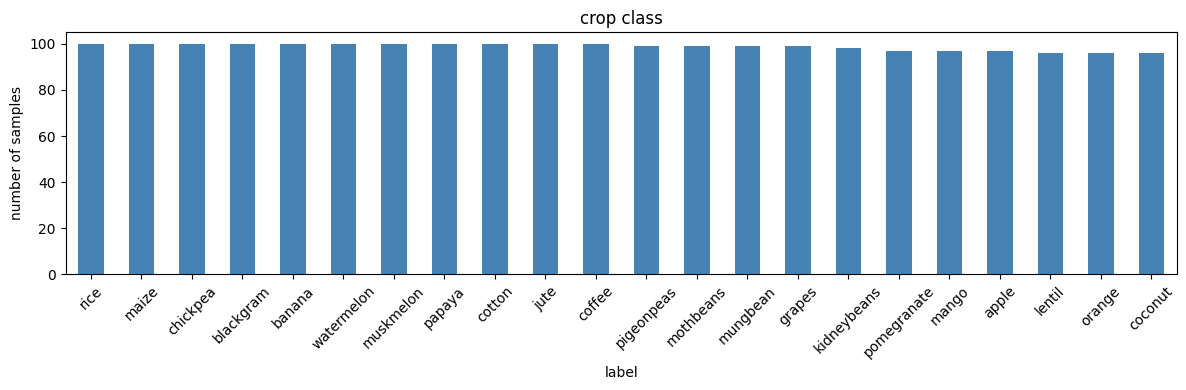

In [61]:
#SMOTE 
#check distribution

counts = df['label'].value_counts()
print(counts)
print(f"\n Most common: {counts.max()} samples")
print(f"Least common: {counts.min()} samples")
print(f"Imbalance ratio: {counts.max()/counts.min():.1f}x")

#visualise
plt.figure(figsize=(12,4))
counts.plot(kind='bar', color='steelblue')
plt.title('crop class')
plt.ylabel('number of samples')
plt.xticks(rotation = 45)
plt.tight_layout()



In [62]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline 

#apply smote on training data only -not on test data
sm = SMOTE(
    random_state=42,
    k_neighbors=5
)

#fit and resample
X_train_sm,y_train_sm = sm.fit_resample(X_train_raw,y_train)

print("before smote:")
print(pd.Series(y_train).value_counts().to_string())
print(f"\n total training samples: {len(y_train)}")

print("after smote:")
print(pd.Series(y_train_sm).value_counts().to_string())
print(f"\n total training samples: {len(y_train_sm)}")

# now every class has same count as majority class

before smote:
1     80
6     80
17    80
21    80
8     80
11    80
15    80
2     80
5     80
3     80
20    80
14    79
13    79
18    79
7     79
12    78
9     78
0     78
19    77
16    77
10    77
4     77

 total training samples: 1738
after smote:
14    80
1     80
19    80
12    80
16    80
6     80
13    80
17    80
9     80
18    80
21    80
8     80
11    80
10    80
4     80
15    80
0     80
2     80
5     80
3     80
20    80
7     80

 total training samples: 1760


In [63]:
#train and evaluate after smote
X_train_sm_sc = scaler.fit_transform(X_train_sm)

rf_smote =RandomForestClassifier(n_estimators=200,random_state=42)
rf_smote.fit(X_train_sm_sc,y_train_sm)
y_pred_smote = rf_smote.predict(X_test_sc)

print(classification_report(y_test,y_pred_smote, target_names=LE.classes_))


              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        19
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        19
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      1.00      1.00        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        19
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        19
      papaya       1.00    

In [64]:
Imblearn_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',SMOTE(random_state=42)),
    ('model',RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))

])

Imblearn_pipe.fit(X_train_raw,y_train)
y_pred_pipe= Imblearn_pipe.predict(X_test_raw)

print("=== SMOTE + class wgts combined ===")
print(f"macro F1: {f1_score(y_test,y_pred_pipe,average='macro'):.3f}")

joblib.dump(Imblearn_pipe,'../models/smote_crop_model.pkl')
print("pipeline saved!")

=== SMOTE + class wgts combined ===
macro F1: 0.998
pipeline saved!


In [65]:
#run gridsearch with imblearn pipeline
from sklearn.model_selection import StratifiedKFold
param_grid = {
    'smote__k_neighbors':[3,5],
    'model__n_estimators':[100,200],
    'model__max_depth':[10,None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    Imblearn_pipe,
    param_grid,cv=cv,
    scoring='f1_macro',
    n_jobs =-1,
    verbose=1
)
gs.fit(X_train_raw,y_train)

print("best param:", gs.best_params_)
print("best macro f1:", round(gs.best_score_,4))

joblib.dump(gs.best_estimator_, '../models/smote_gridsearch.pkl')
joblib.dump(LE, '../models/label_encoder_smote.pkl')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
best param: {'model__max_depth': None, 'model__n_estimators': 100, 'smote__k_neighbors': 3}
best macro f1: 0.9954


['../models/label_encoder_smote.pkl']

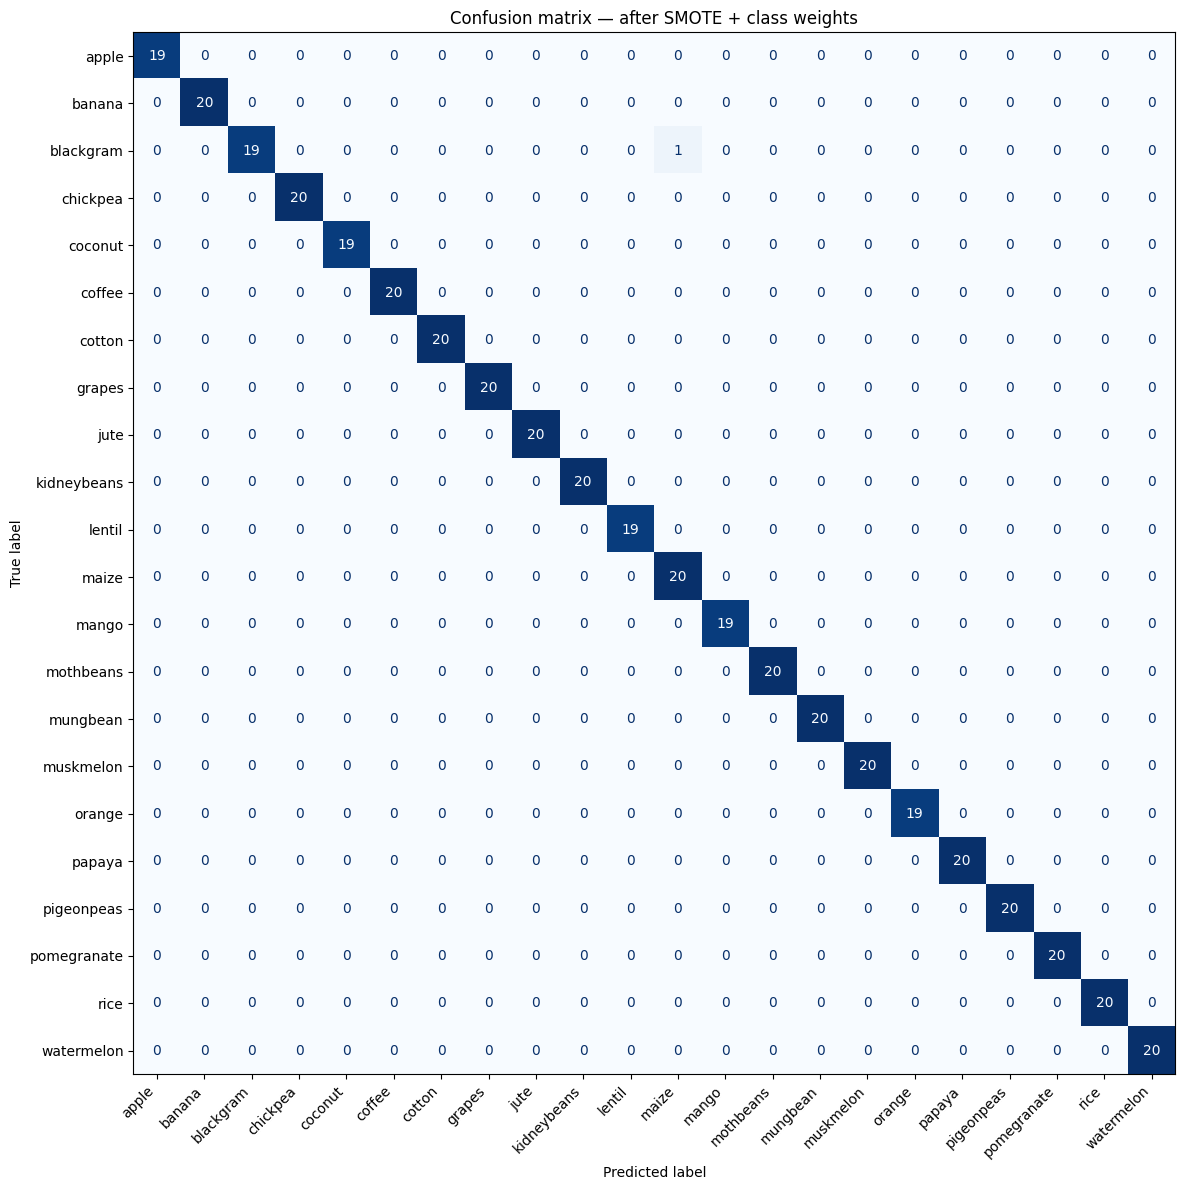

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_final = gs.best_estimator_.predict(X_test_raw)
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=LE.classes_
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion matrix — after SMOTE + class weights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_smote.png')
plt.show()

Deep learning (CNN)

In [67]:
import torch
import torch.nn as nn

In [68]:
x= torch.tensor([[90.0, 42.0, 43.0, 20.8 ,82.0, 6.5, 202.0]])
#one crop sample ^

model = nn.Sequential(
    nn.Linear(7,64), 
    nn.ReLU(),
    nn.Linear(64,32), 
    nn.ReLU(),
    nn.Linear(32,22)      
)

out = model(x)          # creates a tensor of shape (1,22)
print("output shape:", out.shape)     #result : torch.size([1,22])
print("raw scores:", out.detach())
print("predicted class", out.argmax().item())

output shape: torch.Size([1, 22])
raw scores: tensor([[  2.9872,  20.4932,  -0.9844,  -6.9467, -26.4634,  -4.0592,  -0.9670,
          -1.3058, -10.8086,   1.9378,  -8.7360,  11.7339,  -0.0933,  24.3552,
          14.4791,  -3.9384,   4.2694, -12.3971,  -7.7058,  -3.9132,  -1.7134,
           5.1073]])
predicted class 13


In [69]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f" using device : {device}")

 using device : cpu


In [81]:
arr = x.numpy()
print(arr)
t = torch.from_numpy(arr)
print(t)


[[ 90.   42.   43.   20.8  82.    6.5 202. ]]
tensor([[ 90.0000,  42.0000,  43.0000,  20.8000,  82.0000,   6.5000, 202.0000]])


In [86]:
sq = x.squeeze()
print(sq)
print(sq.shape)
unsq= x.unsqueeze(0)
print(x)
print(unsq.shape)

tensor([ 90.0000,  42.0000,  43.0000,  20.8000,  82.0000,   6.5000, 202.0000])
torch.Size([7])
tensor([[ 90.0000,  42.0000,  43.0000,  20.8000,  82.0000,   6.5000, 202.0000]])
torch.Size([1, 1, 7])


In [85]:
x = x.to(device) 
#send to cpu/cuda/mps

In [88]:
#gradient tracking
w = torch.tensor([0.3,0.7,0.2], requires_grad=True)
x= torch.tensor([90.0,42.0, 43.0])

#forward pass
y = (w*x).sum()+ 5
loss = (y-100)**2 

#backward pass = computes d(loss)/d(w) auto...
loss.backward()

print(w.grad)

tensor([-5400., -2520., -2580.])
